# ADAM vs IDBD on the `synthetic_data_v2` winner

One-off scratchpad. Loads the `synthetic_data_v2` data and the best model from the latest run,
then refits its parameters twice — once with Adam, once with IDBD (Sutton 1992) — using the
*same* JAX model / loss / evaluate path as production scoring, so the two optimizers are the
only thing that differs.

Fitted parameters are left in `adam_params` / `idbd_params` (JAX pytrees) plus a tidy DataFrame
for inspection at the end.

**Winner selection:** best `validate.final` loss if the run reached validation, otherwise best
`discover.final`. It is refit on whichever split it was ranked on.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from jax.flatten_util import ravel_pytree

from edgar.io.config import Config
from edgar.io.task_spec import TaskSpec
from edgar.evolution.population import Population
from edgar.evolution.program import NotValidated
from edgar.scoring.scoring import _get_params, _make_optimizer, _eval_loss, default_evaluate
from edgar.scoring.utils import _safe_loss

REPO = Path.cwd()
PROJECT = "synthetic_data_v2"

# IDBD meta step-size (theta). Tune this — it is what makes IDBD competitive.
META_LEARNING_RATE = 0.001

# Starting point for the fit: True uses the winner's parameter_estimator (as in a
# real run); False broadcasts the model's DEFAULT_PARAMS across all samples instead.
USE_PARAM_ESTIMATOR = True

In [2]:
# --- locate the latest run (edit RUN_DIR to pin a specific one) ---
def latest_run(project):
    pops = sorted(
        (REPO / "program_databases" / project).rglob("population.jsonl"),
        key=lambda p: p.stat().st_mtime,
    )
    if not pops:
        raise FileNotFoundError(f"no population.jsonl under {project}")
    return pops[-1].parent

RUN_DIR = latest_run(PROJECT)
print("run dir:", RUN_DIR)

run dir: /home/dabin/code/EDGAR-gamma/program_databases/synthetic_data_v2/2026-07-14/21-44-55


In [3]:
# --- rebuild the exact task spec that produced this run (data, loss, evaluate) ---
config = Config.from_taskspec(RUN_DIR / "task_spec.yaml")
spec = TaskSpec.from_config(config)
loss_fn = spec.loss_fn
evaluate_fn = spec.evaluate_fn or default_evaluate

X_discover, X_validate, X_eval = spec.load_data_fn(
    data_path=spec.io["data_path"], **spec.project_params
)
print("discover train/test x:", X_discover[0]["x"].shape, X_discover[1]["x"].shape)
print("validate train/test x:", X_validate[0]["x"].shape, X_validate[1]["x"].shape)

discover train/test x: (16, 3, 100) (16, 2, 100)
validate train/test x: (16, 3, 100) (16, 2, 100)


In [4]:
# --- load population, pick the winning program ---
def pick_winner(pop):
    """Best by validate.final if any validated, else best by discover.final."""
    validated = [
        p
        for p in pop
        if not isinstance(p.program_losses.validate.final, NotValidated)
        and p.program_losses.validate.final is not None
    ]
    if validated:
        best = min(validated, key=lambda p: _safe_loss(p.program_losses.validate.final))
        return best, "validate"
    scored = [p for p in pop if p.program_losses.discover.final is not None]
    if not scored:
        raise RuntimeError("no scored programs in population")
    best = min(scored, key=lambda p: _safe_loss(p.program_losses.discover.final))
    return best, "discover"

pop = Population.load(str(RUN_DIR / "population.jsonl"))
winner, split = pick_winner(pop)
data_train, data_test = X_validate if split == "validate" else X_discover
won_loss = getattr(winner.program_losses, split).final

print(f"winner: #{winner.idx}  {winner.name}")
print(f"ranked on '{split}' split, {split}.final = {won_loss:.6f},  n_params = {winner.n_params}")

winner: #501  Dynamic-Bias Saturating Multi-Harmonic Autoregressive Model
ranked on 'discover' split, discover.final = 0.000055,  n_params = 16


In [5]:
# --- inspect the winning model's source ---
print(winner.code.model)

"""
**(1) Analysis of Parent Models and Their Shortcomings:**

*   **Gaussian Mixture Autoregressive Model (Previous Model 1, Loss 0.0637):** This model used a linear AR(3) core (`a_1 x_t + a_2 x_{t-1} + a_3 x_{t-2}`) and added two Gaussian basis functions of `x_t` for non-linearity. While its reasoning highlighted the local approximation capabilities of Gaussians, the high loss compared to the subsequent model indicates that this approach was insufficient for capturing the complex, multi-modal, and often oscillatory dynamics of the particle activity. The residual plots (blue lines) showed substantial systematic errors, and the state-space predictions (blue dots) often deviated significantly from the true data (black dots), failing to capture sharp turns and complex curvatures.

*   **Autoregressive Multi-Harmonic Quadratic-Cubic Nonlinear Model (Previous Model 2, Loss 7.22058e-05):** This model achieved exceptionally low loss, nearly perfectly fitting the data in the state-space plots

In [6]:
# --- compile the winner and get the shared starting parameters ---
model_fn = winner.compile_model()

if USE_PARAM_ESTIMATOR:
    param_est_fn = winner.compile_param_est()
    params_init = _get_params(param_est_fn, winner.default_params, data_train)
    src = "parameter_estimator"
else:
    # broadcast the model's DEFAULT_PARAMS across every sample (no estimator)
    n_samples = next(iter(data_train.values())).shape[0]
    params_init = jax.tree_util.tree_map(
        lambda v: jnp.stack([jnp.asarray(v)] * n_samples), winner.default_params
    )
    src = "DEFAULT_PARAMS (broadcast)"

init_train = _eval_loss(model_fn, loss_fn, evaluate_fn, params_init, data_train)
init_test = _eval_loss(model_fn, loss_fn, evaluate_fn, params_init, data_test)
print(f"init from: {src}")
print(f"initial loss  train={init_train:.6f}  test={init_test:.6f}")
print("param keys:", list(params_init))

init from: parameter_estimator
initial loss  train=0.008930  test=0.008967
param keys: ['offset', 'w_L1', 'w_L2', 'w_L3', 'A_T', 'k_T', 'B_T', 'gamma', 'A_S1', 'k_S1', 'phi_S1', 'A_S2', 'k_S2', 'phi_S2', 'A_C', 'A_Q']


In [7]:
# --- optimization loop mirroring edgar.scoring._optimize, but recording the loss curve ---
def fit(gd_config):
    flat, unflatten = ravel_pytree(params_init)

    def total_loss(flat_p):
        out, tgt = evaluate_fn(model_fn, data_train, unflatten(flat_p))
        return jnp.mean(loss_fn(out, tgt))

    loss_and_grad = jax.jit(jax.value_and_grad(total_loss))
    opt = _make_optimizer(gd_config)
    opt_state = opt.init(flat)
    best_loss, best_flat = float("inf"), flat
    history = []
    for _ in range(1, gd_config["max_iter"] + 1):
        loss_val, grad = loss_and_grad(flat)
        history.append(float(loss_val))
        if not jnp.isfinite(loss_val):
            break
        if float(loss_val) < best_loss:
            best_loss, best_flat = float(loss_val), flat.copy()
        updates, opt_state = opt.update(grad, opt_state, flat)
        flat = flat + updates
    return unflatten(best_flat), best_loss, np.array(history)

base_gd = spec.scoring["gradient_descent"]
adam_gd = {**base_gd, "optimizer": "adam"}
idbd_gd = {**base_gd, "optimizer": "idbd", "meta_learning_rate": META_LEARNING_RATE}
print("learning_rate =", base_gd["learning_rate"], " max_iter =", base_gd["max_iter"],
      " meta_learning_rate =", META_LEARNING_RATE)

learning_rate = 0.003  max_iter = 1000  meta_learning_rate = 0.001


In [8]:
adam_params, adam_best, adam_hist = fit(adam_gd)
idbd_params, idbd_best, idbd_hist = fit(idbd_gd)

adam_test = _eval_loss(model_fn, loss_fn, evaluate_fn, adam_params, data_test)
idbd_test = _eval_loss(model_fn, loss_fn, evaluate_fn, idbd_params, data_test)

summary = pd.DataFrame(
    {
        "best_train_loss": [adam_best, idbd_best],
        "final_train_loss": [adam_hist[-1], idbd_hist[-1]],
        "test_loss": [adam_test, idbd_test],
    },
    index=["adam", "idbd"],
)
summary

,best_train_loss,final_train_loss,test_loss
adam,0.000037,0.000037,0.000039
idbd,0.007306,0.007306,0.007195


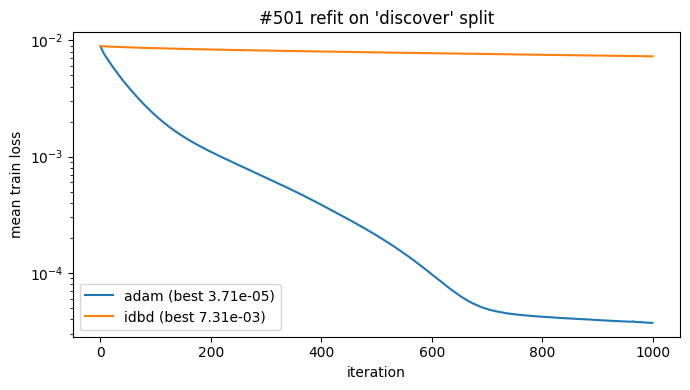

In [9]:
# --- training loss curves ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(adam_hist, label=f"adam (best {adam_best:.2e})")
ax.plot(idbd_hist, label=f"idbd (best {idbd_best:.2e})")
ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel("mean train loss")
ax.set_title(f"#{winner.idx} refit on '{split}' split")
ax.legend()
plt.tight_layout()
plt.show()

## Sweep `learning_rate` × `meta_learning_rate` (IDBD)

IDBD's initial per-parameter step size is `learning_rate`; `theta` (= `meta_learning_rate`) only
controls how fast those step sizes *drift* from that start. The grid below fits IDBD for every
`(learning_rate, theta)` pair and reports the best train loss, with Adam at each `learning_rate`
as a reference. `theta = 0` freezes adaptation (pure SGD at `learning_rate`), so comparing a row
across columns shows how much adaptation actually buys at that base rate.

In [26]:
# --- sweep grids (edit these) ---
LR_SWEEP = [0.1, 0.3, 1.0, 3.0]
THETA_SWEEP = [0.0001, 0.001, 0.1, 1.0, 10.0]

idbd_grid = pd.DataFrame(index=LR_SWEEP, columns=THETA_SWEEP, dtype=float)
adam_ref = {}
for lr in LR_SWEEP:
    _, adam_ref[lr], _ = fit({**base_gd, "optimizer": "adam", "learning_rate": lr})
    for th in THETA_SWEEP:
        _, best, _ = fit(
            {**base_gd, "optimizer": "idbd", "learning_rate": lr, "meta_learning_rate": th}
        )
        idbd_grid.loc[lr, th] = best

idbd_grid.index.name = "learning_rate"
idbd_grid.columns.name = "theta"
print("IDBD best train loss by (learning_rate, theta):")
print(idbd_grid.to_string(float_format=lambda v: f"{v:.2e}"))
print("\nAdam best train loss by learning_rate:")
for lr in LR_SWEEP:
    print(f"  lr={lr:<7} {adam_ref[lr]:.2e}")

IDBD best train loss by (learning_rate, theta):
theta          0.0001   0.0010   0.1000   1.0000   10.0000
learning_rate                                             
0.1           4.42e-03 4.42e-03 3.63e-03 3.63e-03 3.61e-03
0.3           2.90e-03 3.07e-03 3.15e-03 3.20e-03 3.01e-03
1.0           1.22e-03 1.54e-03 3.99e-04 4.45e-03 5.31e-04
3.0           4.45e-03 4.45e-03 4.45e-03 4.45e-03 4.45e-03

Adam best train loss by learning_rate:
  lr=0.1     3.37e-05
  lr=0.3     1.03e-04
  lr=1.0     4.45e-03
  lr=3.0     4.45e-03


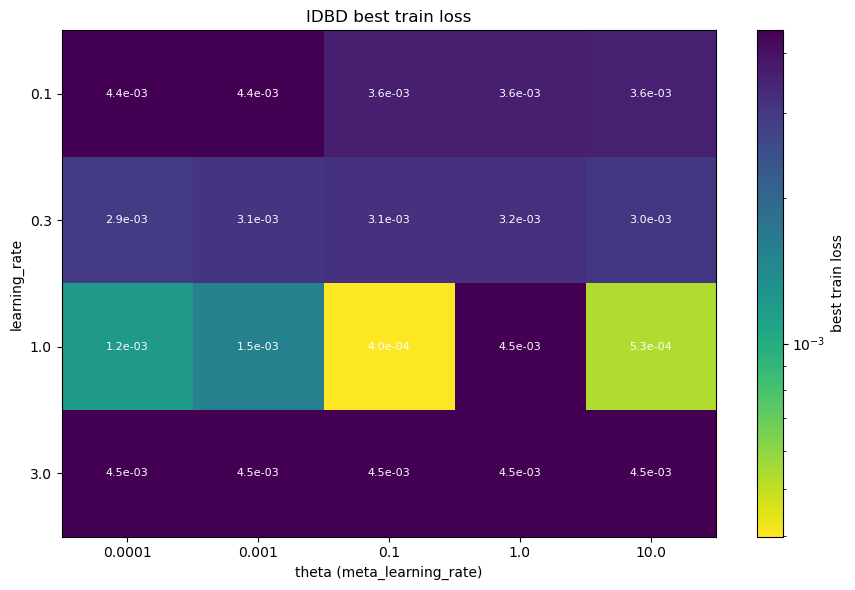

In [27]:
# --- heatmap of the IDBD grid (log color scale) ---
from matplotlib.colors import LogNorm

vals = idbd_grid.to_numpy(dtype=float)
finite = vals[np.isfinite(vals)]
fig, ax = plt.subplots(figsize=(1.4 * len(THETA_SWEEP) + 2, 1.0 * len(LR_SWEEP) + 2))
im = ax.imshow(
    vals,
    cmap="viridis_r",
    norm=LogNorm(vmin=finite.min(), vmax=finite.max()) if finite.size else None,
    aspect="auto",
)
ax.set_xticks(range(len(THETA_SWEEP)), [str(t) for t in THETA_SWEEP])
ax.set_yticks(range(len(LR_SWEEP)), [str(lr) for lr in LR_SWEEP])
ax.set_xlabel("theta (meta_learning_rate)")
ax.set_ylabel("learning_rate")
ax.set_title("IDBD best train loss")
for i in range(len(LR_SWEEP)):
    for j in range(len(THETA_SWEEP)):
        v = vals[i, j]
        txt = f"{v:.1e}" if np.isfinite(v) else "nan"
        ax.text(j, i, txt, ha="center", va="center", color="w", fontsize=8)
fig.colorbar(im, ax=ax, label="best train loss")
plt.tight_layout()
plt.show()

## Inspect the fitted parameters

`adam_params` and `idbd_params` are the full JAX pytrees (each leaf shape `(n_samples,)` — one value
per cell). The tables below summarise them; index by cell for per-cell values.

In [12]:
# per-parameter mean across cells, adam vs idbd
rows = {}
for k in params_init:
    a, b = np.asarray(adam_params[k]), np.asarray(idbd_params[k])
    rows[k] = {
        "init_mean": float(np.mean(np.asarray(params_init[k]))),
        "adam_mean": float(a.mean()),
        "idbd_mean": float(b.mean()),
        "mean_abs_diff": float(np.mean(np.abs(a - b))),
    }
pd.DataFrame(rows).T

,init_mean,adam_mean,idbd_mean,mean_abs_diff
offset,0.014111,-0.017938,0.014090,0.040704
w_L1,0.873821,0.763929,0.873633,0.121638
w_L2,-0.075442,-0.002120,-0.074117,0.079550
w_L3,0.000339,-0.000634,-0.000382,0.006662
A_T,-0.744925,-0.905139,-0.745226,0.166404
k_T,2.549301,2.579294,2.549240,0.353790
B_T,-0.021834,0.018420,-0.021778,0.052250
gamma,0.100000,0.047870,0.097915,0.099156
A_S1,-0.023358,0.010914,-0.023446,0.036354
k_S1,2.000000,1.962396,1.999987,0.126402


In [13]:
# full per-cell fitted values for a single cell (change CELL to inspect others)
CELL = 0
pd.DataFrame(
    {
        "init": {k: float(np.asarray(params_init[k])[CELL]) for k in params_init},
        "adam": {k: float(np.asarray(adam_params[k])[CELL]) for k in params_init},
        "idbd": {k: float(np.asarray(idbd_params[k])[CELL]) for k in params_init},
    }
)

,init,adam,idbd
offset,0.008767,0.002342,8.892396e-03
w_L1,1.459399,1.481927,1.459399e+00
w_L2,-0.009615,-0.000446,-9.619468e-03
w_L3,0.001252,0.000697,1.293815e-03
A_T,-0.058320,-0.184605,-5.831811e-02
k_T,2.716373,3.227747,2.716373e+00
B_T,-0.053505,-0.004365,-5.349259e-02
gamma,0.100000,-0.000361,9.997767e-02
A_S1,-0.016065,-0.001759,-1.596258e-02
k_S1,2.000000,1.981368,2.000000e+00
